# Load Tether Analysis XArray Data

This notebook demonstrates how to load and work with tether analysis data exported in XArray format from the PyFMGUI DyNaMo tether analysis tool.

The notebook covers:
1. Loading session data from NetCDF files
2. Loading analysis results from NetCDF files 
3. Basic data exploration and visualization
4. Working with the structured scientific data format

In [1]:
# Import required libraries
# import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from plotly.subplots import make_subplots
import plotly.graph_objects as go

import plotly.express as px



In [2]:
# open csv file as dataframe
csv_file_path = '/Users/evillz/Data/article/2025_07_01_THP1_phd/sessions/batch_analysis_results/detailed_plateau_data.csv'
csv_file_path = '/Users/evillz/Data/article/2025_07_01_THP1_phd/sessions/velocity_normalized_thp1_cell1/batch_analysis_results/detailed_plateau_data.csv'
csv_file_path = '/Users/evillz/Data/article/final_yey/batch_analysis_results/detailed_plateau_data.csv'
csv_file_path = '/Users/evillz/Data/article/final_yey/final/yess/batch_analysis_results/detailed_plateau_data.csv'

df = pd.read_csv(csv_file_path)


In [3]:
# Define the list of tether session CSV files to concatenate
# You can either specify individual files or use glob to find files matching a pattern

import os
import glob

# Method 1: Specify individual session files
tether_session_files = [
    '/Users/evillz/Data/article/2025_07_02_THP1_phd/final/tether_session_20250807_135516_final.csv',
    '/Users/evillz/Data/article/20205_07_22_Thp1_AC10/canti1/cell1/final/tether_session_20250807_135014_final.csv',
    '/Users/evillz/Data/article/2025_07_01_THP1_phd/sessions/velocity_normalized_thp1_cell1/final/tether_session_20250807_113419.csv',
    # Add more session files here as needed
    # '/path/to/session_file_2.csv',
    # '/path/to/session_file_3.csv',
]

# Method 2: Alternatively, use glob to find all session files in a directory
# session_directory = '/Users/evillz/Data/article/2025_07_02_THP1_phd/sessions'
# tether_session_files = glob.glob(os.path.join(session_directory, '**/tether_session_*.csv'), recursive=True)

print(f"Found {len(tether_session_files)} session files to concatenate:")
for file in tether_session_files:
    print(f"  - {os.path.basename(file)}")

# Initialize list to store dataframes
tether_dataframes = []

# Process each session file
for file in tether_session_files:
    print(f"\nProcessing: {os.path.basename(file)}")
    
    try:
        # Read the CSV file
        df_session = pd.read_csv(file)
        
        # Check if this is a metadata row (first row often contains session metadata)
        if len(df_session) > 1 and df_session.iloc[0].get('filename', '').startswith('METADATA'):
            print(f"  Skipping metadata row in {os.path.basename(file)}")
            df_session = df_session.iloc[1:].reset_index(drop=True)
        
        # Add source file information for tracking
        df_session['source_session_file'] = os.path.basename(file)
        
        print(f"  Loaded {len(df_session)} rows from {os.path.basename(file)}")
        tether_dataframes.append(df_session)
        
    except Exception as e:
        print(f"  Error loading {file}: {e}")

# Concatenate all dataframes
if tether_dataframes:
    concatenated_tether_data = pd.concat(tether_dataframes, ignore_index=True)
    print(f"\nSuccessfully concatenated {len(tether_dataframes)} session files")
    print(f"Total rows in concatenated data: {len(concatenated_tether_data)}")
    # print(f"Total unique files: {concatenated_tether_data['filename'].nunique()}")
    
    # Display basic info about the concatenated data
    print(f"\nConcatenated data shape: {concatenated_tether_data.shape}")
    print(f"Columns: {list(concatenated_tether_data.columns)}")
else:
    print("No session files were successfully loaded!")
    concatenated_tether_data = pd.DataFrame()

# save concatenated data to a CSV file
output_file = '/Users/evillz/Data/article/2025_07_02_THP1_phd/final/concatenated_tether_data.csv'
concatenated_tether_data.to_csv(output_file, index=False)
print(f"Saved concatenated data to {output_file}")

Found 3 session files to concatenate:
  - tether_session_20250807_135516_final.csv
  - tether_session_20250807_135014_final.csv
  - tether_session_20250807_113419.csv

Processing: tether_session_20250807_135516_final.csv
  Error loading /Users/evillz/Data/article/2025_07_02_THP1_phd/final/tether_session_20250807_135516_final.csv: [Errno 2] No such file or directory: '/Users/evillz/Data/article/2025_07_02_THP1_phd/final/tether_session_20250807_135516_final.csv'

Processing: tether_session_20250807_135014_final.csv
  Loaded 910 rows from tether_session_20250807_135014_final.csv

Processing: tether_session_20250807_113419.csv
  Loaded 245 rows from tether_session_20250807_113419.csv

Successfully concatenated 2 session files
Total rows in concatenated data: 1155

Concatenated data shape: (1155, 9)
Columns: ['local_file_path', 'file_name', 'bool_good_curve', 'analysis_status', 'calc_ret_vel', 'file_parameters', 'plateau_selections', 'current_file_index', 'source_session_file']


OSError: Cannot save file into a non-existent directory: '/Users/evillz/Data/article/2025_07_02_THP1_phd/final'

In [ ]:
# Cycle through file_idx and plateau_idx, get delta_avg for selected plateaus
# Set N to control how many of the last plateaus to analyze per file
N =1  # Change this value to get the last N plateaus


selected_delta_avg = []
unselected_delta_avg = []
selected_velocity_meta = []
unselected_velocity_meta = []
selected_delta_time = []
selected_slope= []
selected_tether_lifetime_m = []
selected_tether_lifetime_s = []
loading_rate = []

# Group by file_idx to process each file
for file_idx in df['file_idx'].unique():
    file_data = df[df['file_idx'] == file_idx]
    filename = file_data['filename'].iloc[0]  # Get filename for this file_idx
    
    print(f"\nFile {file_idx}: {filename}")
        
    # Get unique plateau indices and sort them to get the last N
    plateau_indices = sorted(file_data['plateau_idx'].unique())
    # last_n_plateaus = plateau_indices[-N-1:-N] if len(plateau_indices) >= N else plateau_indices
    last_n_plateaus = plateau_indices[3:-1] if len(plateau_indices) >= N else plateau_indices
    
    print(f"  Total plateaus: {len(plateau_indices)}, analyzing last {len(last_n_plateaus)} plateaus: {last_n_plateaus}")
    
    # Cycle through only the last N plateaus in this file
    for plateau_idx in last_n_plateaus:
        plateau_data = file_data[file_data['plateau_idx'] == plateau_idx]
        
        if len(plateau_data) > 0:
            row = plateau_data.iloc[0]  # Get the plateau data
            delta_avg = row['delta_avg'] # tether force
            plateau_selected = row['plateau_selected']
            plateau_delta_time = np.round(row['delta_time'], 4) # time for tethering to occur starting from contact point
            plateau_loading_rate = row['mean dN/dt']  #mean derivate dF/dZ 
            plateau_velocity_calc = row['plateau_velocity_calc']  # calculated velocity
            plateau_velocity_meta = int(np.round(row['velocity_metadata'])) # metadata velocity1
            plateau_slope = row['slope']  # Slope of plateau
            plateau_avg_idx = row['plateau_avg']  # index of plateau average value within the plateau
            tether_lifeime_s = row['tether_lifetime_s']  # duration of a plateau in seconds
            
            print(f"  Plateau {plateau_idx}: delta_avg={delta_avg:.2e}, selected={plateau_selected}, \
                    delta_time={plateau_delta_time:.2f}, mean_derivative={plateau_loading_rate:.2e}, \
                    velocity_calc={plateau_velocity_calc:.2e}, velocity_meta={plateau_velocity_meta}")
            
            # Store delta_avg and velocity_metadata based on selection status
            if plateau_selected:
                # store items back into dataframe
                df.loc[plateau_data.index, 'selected_delta_avg'] = delta_avg
                df.loc[plateau_data.index, 'selected_velocity_meta'] = np.nan if plateau_velocity_meta == 0 else -plateau_velocity_meta
                df.loc[plateau_data.index, 'selected_delta_time'] = plateau_delta_time
                df.loc[plateau_data.index, 'selected_slope'] = plateau_slope
                df.loc[plateau_data.index, 'selected_tether_lifetime_m'] = row['tether_lifetime_m']
                df.loc[plateau_data.index, 'selected_tether_lifetime_s'] = tether_lifeime_s 
                df.loc[plateau_data.index, 'loading_rate'] = plateau_loading_rate

                # Create lists for selected values
                # Append NaN if any value is exactly zero, else append the value
                selected_delta_avg.append(np.nan if delta_avg == 0 else delta_avg) #Delta F of average force of plateau
                selected_velocity_meta.append(np.nan if plateau_velocity_meta == 0 else -plateau_velocity_meta)
                selected_delta_time.append(np.nan if plateau_delta_time == 0 else plateau_delta_time) #time of each tether plateau from contact point 
                selected_slope.append(np.nan if plateau_slope == 0 else plateau_slope) #slope of plateau segment df/dz
                selected_tether_lifetime_m.append(np.nan if row['tether_lifetime_m'] == 0 else row['tether_lifetime_m']) #
                selected_tether_lifetime_s.append(np.nan if tether_lifeime_s == 0 else tether_lifeime_s)
                loading_rate.append(np.nan if plateau_loading_rate == 0 else plateau_loading_rate)
            else:
                unselected_delta_avg.append(delta_avg)
                unselected_velocity_meta.append(plateau_velocity_meta)

# # put back into dataframe all the selected plateau metadata
# selected_mask = df['plateau_selected']
# selected_indices = df.index[selected_mask]

# for col, vals in zip(
#     ['selected_delta_avg', 'selected_velocity_meta', 'selected_delta_time', 'selected_slope', 'selected_distance_detachment', 'selected_tether_lifetime'],
#     [selected_delta_avg, selected_velocity_meta, selected_delta_time, selected_slope, selected_distance_detachment, selected_tether_lifetime]
# ):
#     # Only assign if lengths match
#     if len(selected_indices) == len(vals):
#         df.loc[selected_indices, col] = vals
#     else:
#         print(f"Warning: Length mismatch for {col}: {len(selected_indices)} rows, {len(vals)} values. Skipping assignment for this column.")



File 1: fcurve_THP1_AC10_FastVelocities__2025.07.22_16.10.02.35.tdms
  Total plateaus: 6, analyzing last 2 plateaus: [np.int64(3), np.int64(4)]
  Plateau 3: delta_avg=-2.07e-10, selected=True,                     delta_time=0.00, mean_derivative=5.10e-10,                     velocity_calc=-1.56e+03, velocity_meta=-2300
  Plateau 4: delta_avg=-1.34e-11, selected=True,                     delta_time=0.00, mean_derivative=3.84e-10,                     velocity_calc=-1.71e+03, velocity_meta=-2300

File 2: fcurve_THP1_AC10_FastVelocities__2025.07.22_16.10.09.53.tdms
  Total plateaus: 3, analyzing last 0 plateaus: []

File 3: fcurve_THP1_AC10_FastVelocities__2025.07.22_16.08.28.32.tdms
  Total plateaus: 4, analyzing last 0 plateaus: []

File 4: fcurve_THP1_AC10_FastVelocities__2025.07.22_16.03.21.06.tdms
  Total plateaus: 2, analyzing last 0 plateaus: []

File 5: fcurve_THP1_AC10_FastVelocities__2025.07.22_16.08.36.00.tdms
  Total plateaus: 6, analyzing last 2 plateaus: [np.int64(3), np.int

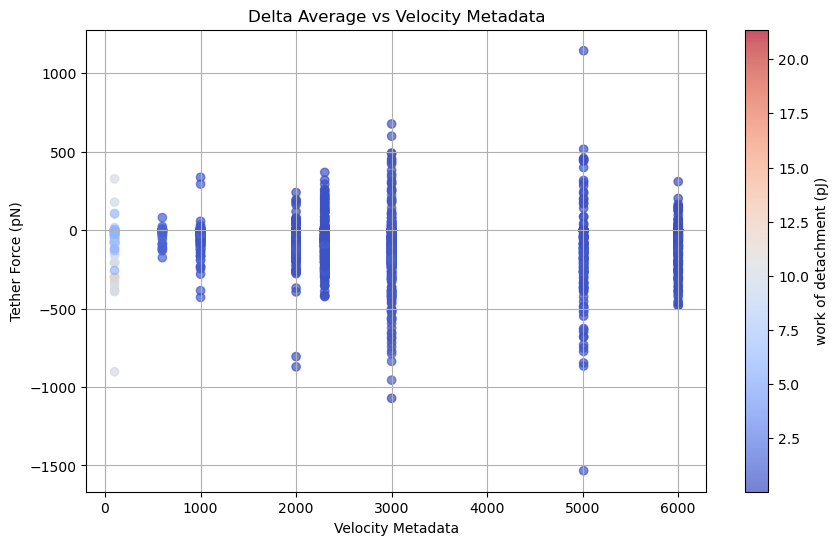

In [ ]:
# plot delta_avg vs velocity_metadata
plt.figure(figsize=(10, 6))
plt.scatter(-df['velocity_metadata'], df['delta_avg']*1e12, c=df['mean dN/dt']*1e9, cmap='coolwarm', alpha=0.7)
plt.colorbar(label='work of detachment (pJ)')
plt.xlabel('Velocity Metadata')
plt.ylabel('Tether Force (pN)')
plt.title('Delta Average vs Velocity Metadata')
# plt.gca().invert_xaxis()
plt.grid()
plt.show()  

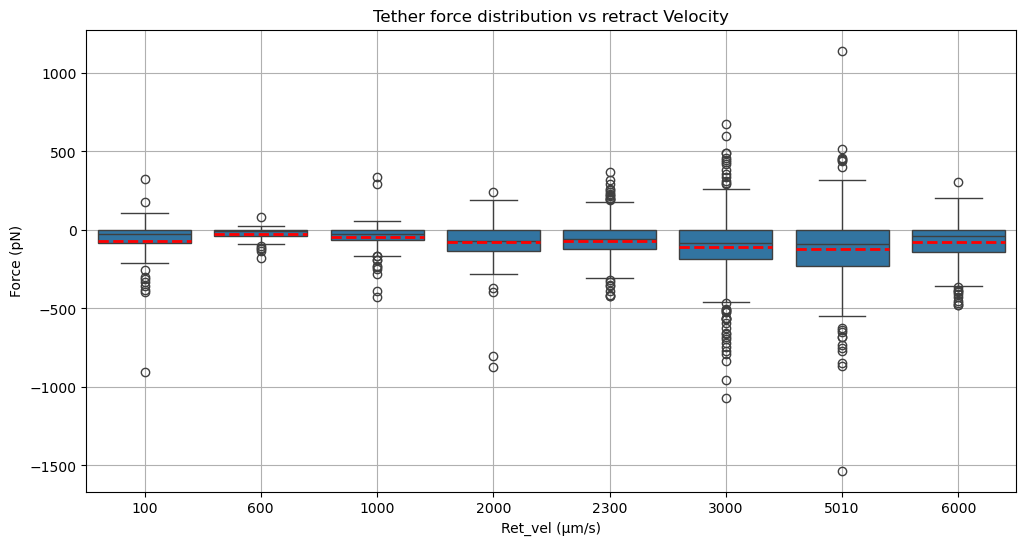

In [ ]:

plt.figure(figsize=(12, 6))
sns.boxplot(
    x=np.round(-df['velocity_metadata'].astype(int)),
    y=df['delta_avg']*1e12,
    data=df,
    showmeans=True,
    meanline=True,
    meanprops={'color': 'red', 'linewidth': 2}
)
plt.xlabel('Ret_vel (µm/s)')
plt.ylabel('Force (pN)')
plt.title('Tether force distribution vs retract Velocity')
plt.grid()
# plt.gca().invert_xaxis()
plt.show()

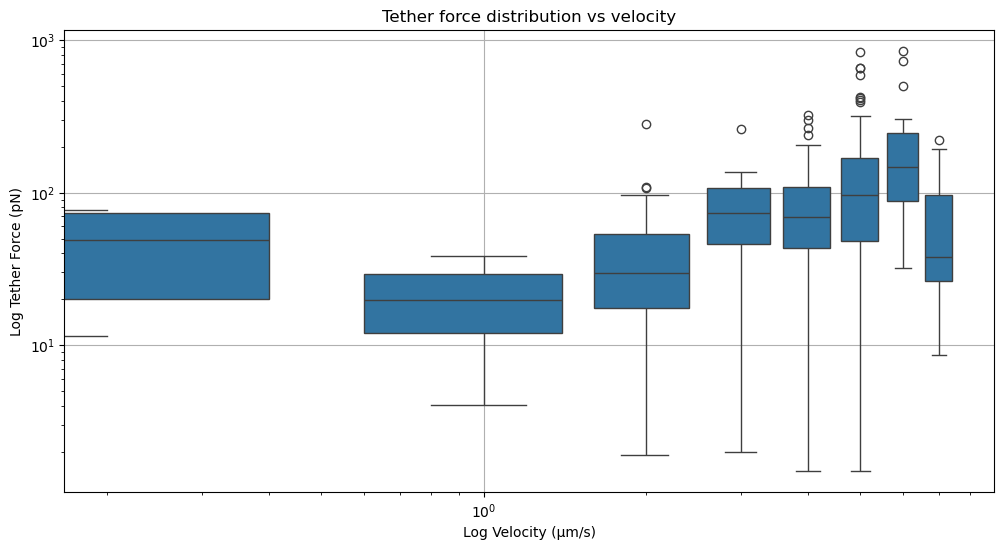

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    x=np.round(np.array(selected_velocity_meta).astype(int)),
    y=np.abs(np.array(selected_delta_avg))*1e12
)
plt.xlabel('Log Velocity (µm/s)')
plt.ylabel('Log Tether Force (pN)')
plt.title('Tether force distribution vs velocity')
plt.grid()
plt.xscale('log')
plt.yscale('log')
# plt.gca().invert_xaxis()
plt.show()

In [ ]:
# Filter out detachment times and their respective velocities that are in the order of 1e-6 seconds
filtered_df = df[df['delta_time'] > 1e-6]   



filtered_df.head()

,filename,file_path,file_idx,plateau_idx,plateau_selected,plateau_avg_idx,plateau_avg,delta_avg,delta_time,mean dN/dt,...,slope,tether_lifetime_m,tether_lifetime_s,selected_delta_avg,selected_velocity_meta,selected_delta_time,selected_slope,selected_tether_lifetime_m,selected_tether_lifetime_s,loading_rate
0,fcurve_THP1_AC10_FastVelocities__2025.07.22_16...,/Users/evillz/Data/article/20205_07_22_Thp1_AC...,1,0,True,394,4.223906e-10,5.397237e-11,0.000788,3.420119e-10,...,0.000294,0.000002,0.001898,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,fcurve_THP1_AC10_FastVelocities__2025.07.22_16...,/Users/evillz/Data/article/20205_07_22_Thp1_AC...,1,1,True,979,4.763630e-10,-1.376840e-10,0.001958,4.844074e-10,...,-0.000558,0.000004,0.000128,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,fcurve_THP1_AC10_FastVelocities__2025.07.22_16...,/Users/evillz/Data/article/20205_07_22_Thp1_AC...,1,2,True,1055,3.386789e-10,-1.391720e-10,0.002110,4.542201e-10,...,-0.000489,0.000004,0.000146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,fcurve_THP1_AC10_FastVelocities__2025.07.22_16...,/Users/evillz/Data/article/20205_07_22_Thp1_AC...,1,3,True,1119,1.995069e-10,-2.065781e-10,0.002238,5.100120e-10,...,-0.000553,0.000004,0.000056,-2.065781e-10,2300.0,0.0022,-0.000553,0.000004,0.000056,5.100120e-10
4,fcurve_THP1_AC10_FastVelocities__2025.07.22_16...,/Users/evillz/Data/article/20205_07_22_Thp1_AC...,1,4,True,1388,-7.071206e-12,-1.343080e-11,0.002776,3.843366e-10,...,0.000009,0.000005,0.000858,-1.343080e-11,2300.0,0.0028,0.000009,0.000005,0.000858,3.843366e-10


In [ ]:

fig = make_subplots(
    rows=3, cols=2,
    vertical_spacing=0.1,
    subplot_titles=[
        "Slope Plateau vs velocity",
        "Tether plateau Force vs velocity",
        "Tether Detachment Time vs velocity",
        "Detachment Distance vs velocity",
        "Tether lifetime vs tether extraction force",
        "Rupture force vs loading rate"
    ]
)

# 1. Plateau Slope vs Velocity Metadata (violin plot)
fig.add_trace(
    go.Box(
        x=np.round(np.array(selected_velocity_meta).astype(int)),
        y=np.log10((np.array(selected_slope)*1e6)),
        name='Plateau Slope (dN/dµm)',
        # box_visible=True,
        # meanline_visible=True,
        marker_color='purple',
        boxmean='sd',
        boxpoints='outliers',
        # marker_color='blue',
        # name='Tether Force'
    ),
    row=1, col=1
)

# 2. Tether Force Distribution vs Velocity Metadata (boxplot)
fig.add_trace(
    go.Box(
        x=np.round(np.array(selected_velocity_meta).astype(int)),
        y=np.log10(np.abs((np.array(selected_delta_avg))*1e12)),
        boxmean='sd',
        # boxpoints='outliers',
        marker_color='blue',
        name='Tether Force',
        boxpoints='outliers',  # Show all points for better visibility

    ),
    row=1, col=2
)
# Filter out detachment times smaller than 1e-6 seconds and create boxplot
selected_delta_time_array = np.array(selected_delta_time)
selected_velocity_meta_array = np.array(selected_velocity_meta)

# Create mask for times >= 1e-6 seconds
time_filter_mask = selected_delta_time_array >= 1e-4

# Apply filter to both arrays
filtered_delta_time = selected_delta_time_array[time_filter_mask]
filtered_velocity_meta = selected_velocity_meta_array[time_filter_mask]

# Remove NaN values
valid_mask = ~(np.isnan(filtered_delta_time) | np.isnan(filtered_velocity_meta))
filtered_delta_time_clean = filtered_delta_time[valid_mask]
filtered_velocity_meta_clean = filtered_velocity_meta[valid_mask]


# 3. Detachment Time vs Velocity (boxplot)
fig.add_trace(
    go.Box(
        x=np.round(filtered_velocity_meta_clean.astype(int)),
        y=np.log10(filtered_delta_time_clean * 1e3),
        boxmean='sd',
        boxpoints='outliers',
        marker_color='green',
        name='Detachment Time (ms)'  # Changed to ms for clarity
    ),
    row=2, col=1
)

# 4. Tether Lifetime vs Velocity (boxplot, log scale)
fig.add_trace(
    go.Box(
        x=np.round(np.array(selected_velocity_meta).astype(int)),
        y=np.log10(np.array(selected_tether_lifetime_m)*1e6) ,
        boxmean='sd',
        boxpoints='outliers',
        marker_color='orange',
        name='Detachment Distance'
    ),
    row=2, col=2
)

# 5. Tether detachment distance vs binned extraction force in ascending order, with loading rates sorted accordingly
force_array = np.abs(np.array(selected_delta_avg)) * 1e12
tether_lifetime_s_array = np.array(selected_tether_lifetime_s) * 1e6
loading_rate_array = np.array(loading_rate)

# Remove NaN values from all arrays before binning
valid_mask = ~(np.isnan(force_array) | np.isnan(tether_lifetime_s_array) | np.isnan(loading_rate_array))
force_array_clean = force_array[valid_mask]
tether_lifetime_s_array_clean = tether_lifetime_s_array[valid_mask]
loading_rate_array_clean = loading_rate_array[valid_mask]

# Sort by force in ascending order
sorted_indices = np.argsort(force_array_clean)
force_array_sorted = force_array_clean[sorted_indices]
distance_array_sorted = tether_lifetime_s_array_clean[sorted_indices]
loading_rate_sorted = loading_rate_array_clean[sorted_indices]

# Choose number of bins (e.g., 4 bins)
num_bins = 4

# Bin the sorted forces into quantiles
force_bins = np.quantile(force_array_sorted, np.linspace(0, 1, num_bins + 1))
force_bin_labels = [f"{int(force_bins[i])}-{int(force_bins[i+1])} pN" for i in range(num_bins)]

# Assign each force to a bin
force_bin_indices = np.digitize(force_array_sorted, force_bins[1:], right=True)
force_bin_labels_for_points = [force_bin_labels[min(i, len(force_bin_labels)-1)] for i in force_bin_indices]


# Bin the loading rates into quantiles (optional: same number of bins)
loading_rate_bins = np.quantile(loading_rate_sorted, np.linspace(0, 1, num_bins + 1))
loading_rate_bin_labels = [
    f"{int(loading_rate_bins[i])}-{int(loading_rate_bins[i+1])} pN/s"
    for i in range(num_bins)
]
# # Add small epsilon to ensure unique bin edges if necessary
# epsilon = 1e-9
# loading_rate_bins = np.unique(loading_rate_bins + np.arange(len(loading_rate_bins)) * epsilon)

# Assign each loading rate to a bin
loading_rate_bin_indices = np.digitize(loading_rate_sorted, loading_rate_bins[1:], right=True)
loading_rate_bin_labels_for_points = [
    loading_rate_bin_labels[min(i, len(loading_rate_bin_labels)-1)]
    for i in loading_rate_bin_indices
]

# 4. Tether Detachment Distance vs Force (binned, sorted)
fig.add_trace(
    go.Box(
        x=force_bin_labels_for_points,
        y=np.log10((distance_array_sorted)*1e-6 ),  # Convert to µm
        boxmean='sd',
        boxpoints='outliers',
        marker_color='red',
        name='Detachment Distance vs Force (binned, sorted)'
    ),
    row=3, col=1
)

# # 5 Tether Force (binned,sorted) vs loading rate (binned)
# fig.add_trace(
#     go.Box(
#         x=loading_rate_bin_labels_for_points,
#         y=force_array_sorted,
#         boxmean='sd',
#         boxpoints='outliers',
#         marker_color='blue',
#         name='Force vs Loading Rate (binned)'
#     ),
#     row=3, col=2
# )

fig.update_xaxes(title_text="velocity(µm/s)", type='log', row=1, col=1)
fig.update_yaxes(title_text="log10 Plateau Slope (dN/dµm)", row=1, col=1)

fig.update_xaxes(title_text="velocity (µm/s)", type='log', row=1, col=2)
fig.update_yaxes(title_text="log10 Tether Force (pN)", row=1, col=2)

fig.update_xaxes(title_text="velocity (µm/s)", type='log', row=2, col=1)
fig.update_yaxes(title_text="log10 PoC to Plateau avg_id (ms)", row=2, col=1)

fig.update_xaxes(title_text="velocity (µm/s)", type='log', row=2, col=2)
fig.update_yaxes(title_text="log10 Tether distance (µm)", row=2, col=2)

fig.update_xaxes(title_text="Tether Force (N)", row=3, col=1)
fig.update_yaxes(title_text="log10 Tether lifetime (s)", row=3, col=1)

fig.update_xaxes(title_text="Loading rate (N/s)", row=3, col=2)
fig.update_yaxes(title_text="Binned Tether Force (N)", row=3, col=2)


fig.update_layout(height=900, width=1400, title_text="Tether Analysis Summary Plots", showlegend=False)
fig.show()

/var/folders/kc/jykhdgwx4p3696y51hzh6j3r0000gn/T/ipykernel_67664/2779166034.py:18: RuntimeWarning:

invalid value encountered in log10



In [ ]:

saveFile = True
if saveFile:
    path = '/Users/evillz/Data/article/tether_figs/'
    name = 'plateau_analysis_vs_velocity_new'
    fig.write_html(path + name + '.html', full_html=True, include_plotlyjs="include")           

In [ ]:
# Check for negative values in selected_distance_detachment
has_negative = any(val < 0 for val in selected_tether_lifetime_m)
print("Contains negative values:", has_negative)

Contains negative values: False


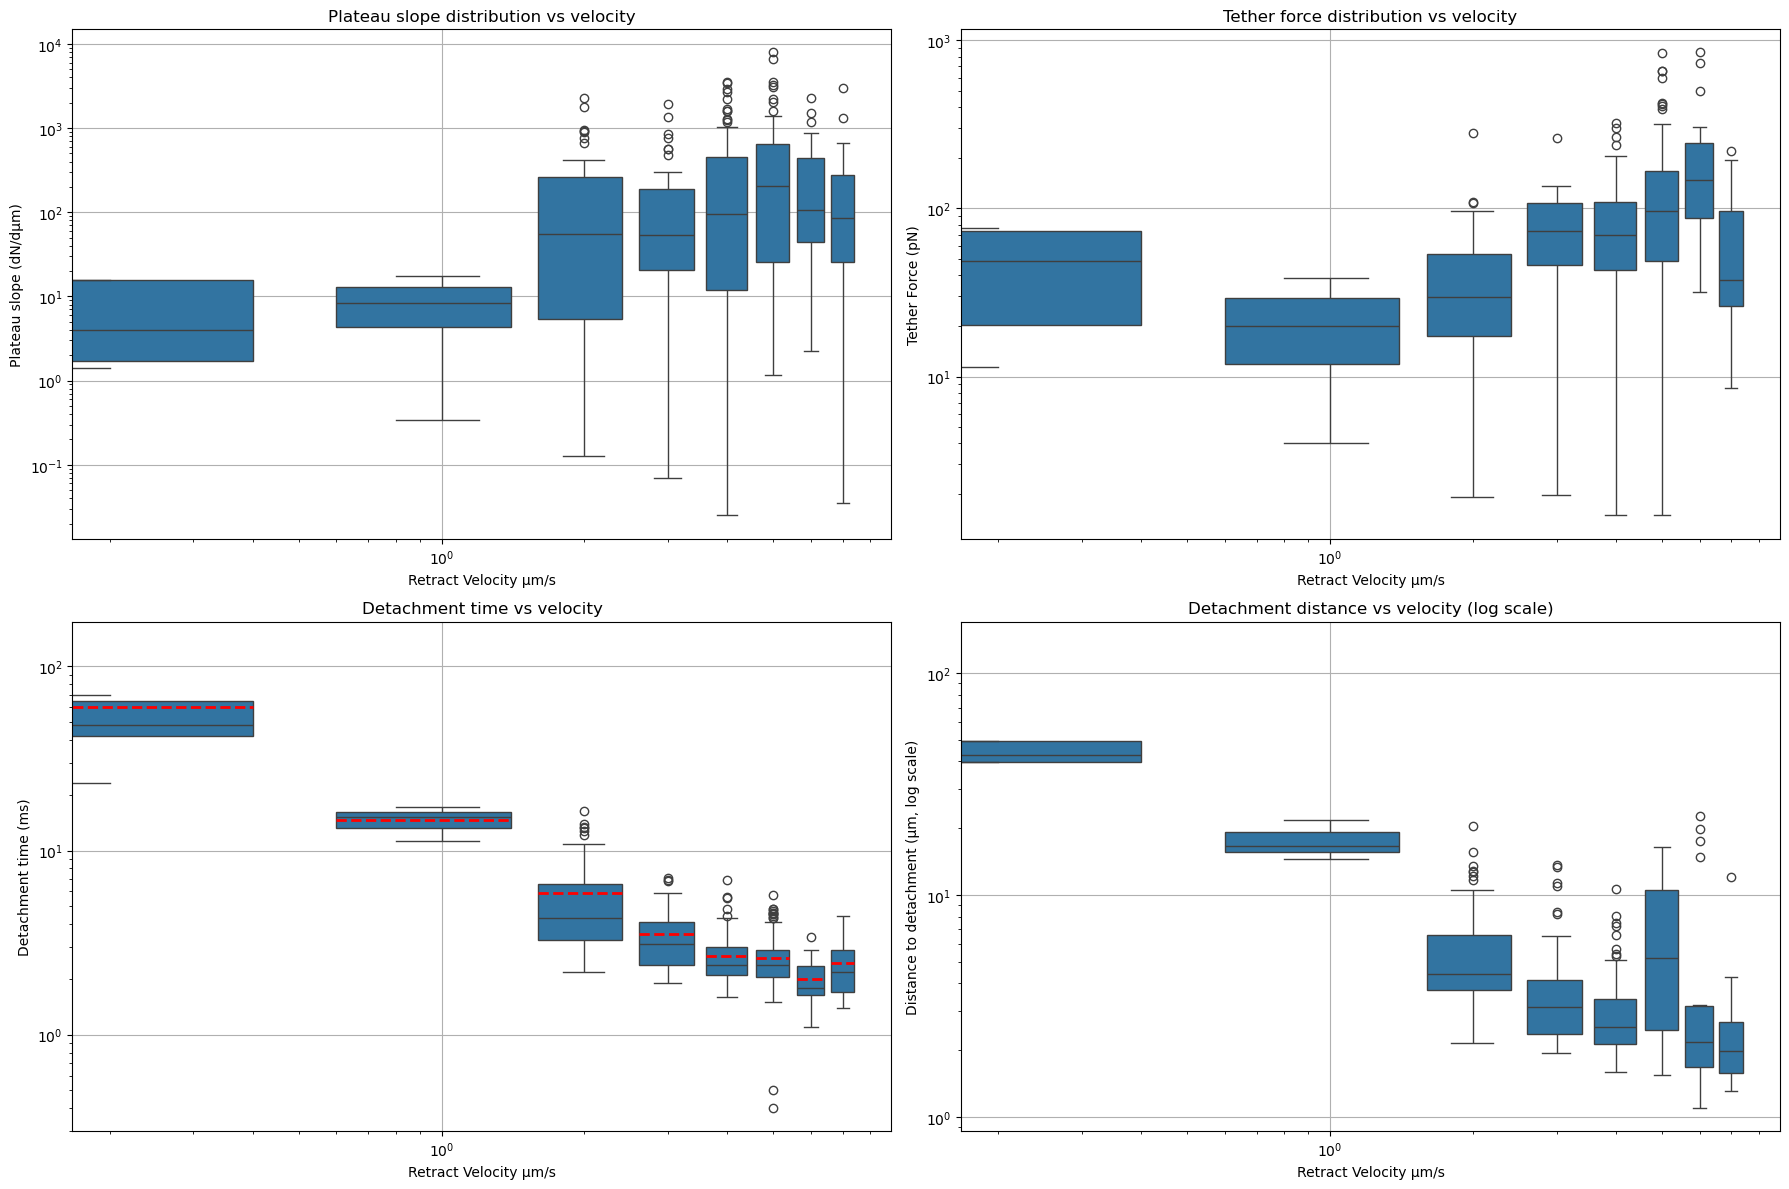

In [ ]:
# plt.figure(figsize=(10, 6))
# plt.hist(np.array(selected_delta_time) * 1e3, bins=50, color='skyblue', edgecolor='black')
# plt.xlabel('Detachment Time (ms)')
# plt.ylabel('Count')
# plt.title('Histogram of Detachment Time (ms)')
# plt.grid(True)
# plt.show()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Plateau Slope vs velocity
sns.boxplot(
    ax=axes[0, 0],
    x=np.round(np.array(selected_velocity_meta).astype(int)),
    y=np.abs(np.array(selected_slope))*1e6
)
axes[0, 0].set_xlabel('Retract Velocity µm/s')
axes[0, 0].set_ylabel('Plateau slope (dN/dµm)')
axes[0, 0].set_xscale('log')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Plateau slope distribution vs velocity')
axes[0, 0].grid()

# 2. Tether Force Distribution vs Velocity
sns.boxplot(
    ax=axes[0, 1],
    x=np.round(np.array(selected_velocity_meta).astype(int)),
    y=np.abs(np.array(selected_delta_avg))*1e12
)
axes[0, 1].set_xlabel('Retract Velocity µm/s')
axes[0, 1].set_ylabel('Tether Force (pN)')
axes[0, 1].set_xscale('log')
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Tether force distribution vs velocity')
axes[0, 1].grid()

# 3. Detachment Time vs Velocity
sns.boxplot(
    ax=axes[1, 0],
    x=np.round(np.array(selected_velocity_meta).astype(int)),
    y=np.array(selected_delta_time) * 1e3,
    showmeans=True,
    meanline=True,
    meanprops={'color': 'red', 'linewidth': 2},
)
axes[1, 0].set_xlabel('Retract Velocity µm/s')
axes[1, 0].set_ylabel('Detachment time (ms)')
axes[1, 0].set_xscale('log')
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Detachment time vs velocity')
axes[1, 0].grid()

# 4. Detachment Distance vs Velocity
sns.boxplot(
    ax=axes[1, 1],
    x=np.round(np.array(selected_velocity_meta).astype(int)),
    y=np.abs(np.array(selected_tether_lifetime_m)*1e6)
)
axes[1, 1].set_xlabel('Retract Velocity µm/s')
axes[1, 1].set_ylabel('Distance to detachment (µm, log scale)')
axes[1, 1].set_xscale('log')
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Detachment distance vs velocity (log scale)')
axes[1, 1].grid()

plt.tight_layout()
plt.show()

In [ ]:
force_pN = np.abs(np.array(selected_delta_avg) * 1e12)
tether_lifetime_ms = np.array(selected_tether_lifetime_s) 

# Remove NaN values from both arrays before binning
valid_mask = ~(np.isnan(force_pN) | np.isnan(tether_lifetime_ms))
force_pN_clean = force_pN[valid_mask]
tether_lifetime_clean = tether_lifetime_ms[valid_mask]

# Filter data to only include forces between 0-60 pN
force_range_mask = (force_pN_clean >= 30) & (force_pN_clean <= 60)
force_pN_filtered = force_pN_clean[force_range_mask]
tether_lifetime_filtered = tether_lifetime_clean[force_range_mask]

# Create bins based on filtered data range
min_force = np.min(force_pN_filtered)
max_force = np.max(force_pN_filtered)
bins = np.logspace(np.log10(min_force), np.log10(max_force), 4)  # 30 bins

force_binned = pd.cut(force_pN_filtered, bins)



# Prepare data for Plotly (Detachment Distance vs Force bins)
detachment_distance_um = np.array(selected_tether_lifetime_m)[valid_mask][force_range_mask] * 1e6  # convert to µm

plot_df_distance = pd.DataFrame({
    'force_binned': force_binned,
    'force_binned_str': force_binned.astype(str),
    'detachment_distance_um': detachment_distance_um,
    'force_midpoint': force_pN_filtered
})

# Sort by force for ascending order
plot_df_distance = plot_df_distance.sort_values('force_midpoint')

fig = px.box(
    plot_df_distance,
    x='force_binned_str',
    y='detachment_distance_um',
    labels={'force_binned_str': 'Extraction force (pN, binned)', 'detachment_distance_um': 'Detachment distance (µm)'},
    title='Detachment Distance vs Extraction Force (0-60 pN, binned, log y)'
)
fig.update_yaxes(type='log')
fig.update_xaxes(tickangle=45)
fig.show()

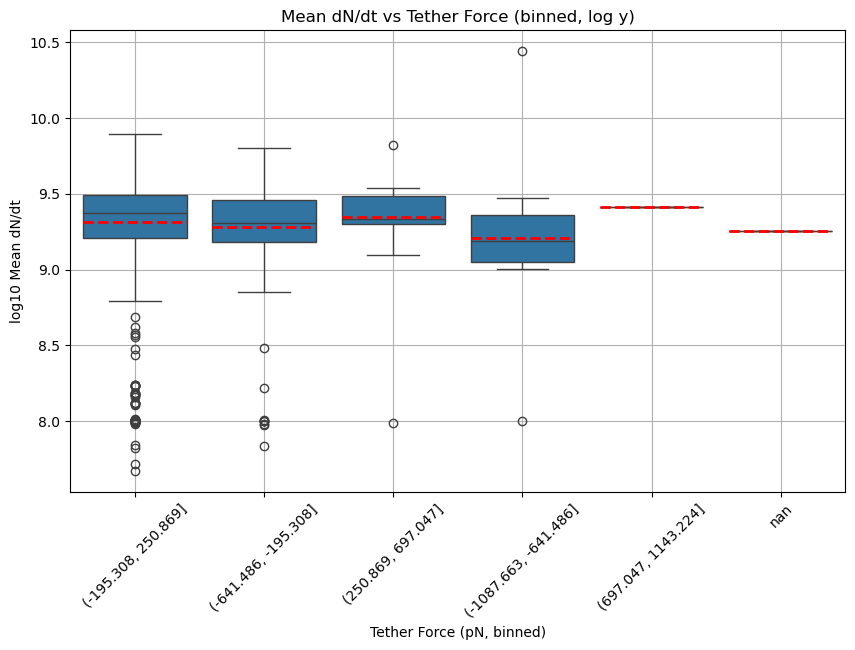

In [ ]:
# Bin the delta_avg (tether force) into 6 bins (adjust as needed)
num_bins = 6
force_pN = df['delta_avg'] * 1e12
bins = np.linspace(force_pN.min(), force_pN.max(), num_bins + 1)
force_binned = pd.cut(force_pN, bins)

plt.figure(figsize=(10, 6))
sns.boxplot(
    x=force_binned.astype(str),
    y=-np.log10(df['mean dN/dt']),
    showmeans=True,
    meanline=True,
    meanprops={'color': 'red', 'linewidth': 2}
)
plt.xlabel('Tether Force (pN, binned)')
plt.ylabel('log10 Mean dN/dt')
plt.title('Mean dN/dt vs Tether Force (binned, log y)')
plt.grid()
plt.xticks(rotation=45)
plt.show()